# Task 2 - Music Segment GraphSAGE and Mel-CNN

This notebook prepares audio segments as graph nodes, compares GraphSAGE with a mel-CNN and pooled-feature MLP, and evaluates temporal, temporal + similarity, and temporal + random edge structures on identical samples and splits.

**Completion status:** executable infrastructure and a synthetic demonstration are available. Real music-context results require locally available audio, the shared Task 1 AudioSet targets and split manifest, training, and frozen test evaluation. Synthetic tone labels are only for verifying the pipeline; their scores do not establish music-context performance.

Real mode uses the current AudioSet task definition, with label columns in exactly the order recorded by Task 1. Audio availability may reduce the cohort, but never changes a sample's inherited split. Compare other tasks again on this same cohort before making cross-task claims.

## 1. Environment and imports

Run from the repository root or `notebooks/`. Install the repository requirements in this notebook's Python environment if needed, then restart the kernel. The saved notebook intentionally contains no old executed scores.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'src' / 'task2').is_dir():
    raise FileNotFoundError('Run from the repository root or notebooks directory.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Repository root:', ROOT)
# %pip install -r {ROOT / 'requirements.txt'}

Repository root: C:\Users\Roman\OneDrive\Documents\Neural_Project


In [2]:
import hashlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from torch.utils.data import DataLoader

from src.task2.audit import audit_saved_graphs
from src.task2.dataset import ProcessedTask2Dataset, collate_task2, dataset_identity
from src.task2.experiment import make_demo_manifest, run_experiment, evaluate_experiment
from src.task2.features import AudioFeatureConfig
from src.task2.manifest import build_aligned_musiccaps_manifest
from src.task2.models import build_task2_model
from src.task2.preprocess import preprocess_manifest
from src.task2.train import Task2TrainConfig
from src.task2.visualize import visualize_graph_examples

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
get_ipython().run_line_magic('matplotlib', 'inline')


C:\Users\Roman\OneDrive\Documents\Neural_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0+cpu
CUDA available: False


## 2. Choose synthetic smoke mode or real-data mode

Synthetic mode creates 30 two-second clips locally, allowing at least 20 distinct graph examples. Its smaller feature configuration and two training epochs keep the check short. Real mode expects the downloaded MusicCaps metadata, the existing Task 1 AudioSet label CSV and split manifest, and audio in `data/raw/musiccaps_audio/`.

Set `REAL_AUDIO_MODE` to `pretrimmed` for clips already cut to the MusicCaps interval, or `full_source` for complete source files that must be sliced at `start_s`. Choose this explicitly so that targets describe the audio actually loaded. No audio is downloaded by this notebook.

In [3]:
USE_SYNTHETIC = True
SEED = 42
SEEDS = (42,) if USE_SYNTHETIC else (42, 43, 44)
DEMO_ROOT = ROOT / 'results' / 'task2' / 'synthetic_verification'
TOP_K = 1 if USE_SYNTHETIC else 2

REAL_METADATA_CSV = ROOT / 'data' / 'raw' / 'musiccaps_official.csv'
REAL_LABELS_CSV = ROOT / 'data' / 'processed' / 'musiccaps_audioset.csv'
REAL_TASK1_MANIFEST = ROOT / 'results' / 'task1' / 'audioset_cpu_20260907' / 'dataset_manifest.json'
REAL_AUDIO_DIR = ROOT / 'data' / 'raw' / 'musiccaps_audio'
REAL_AUDIO_MODE = 'pretrimmed'
REAL_MANIFEST = ROOT / 'data' / 'splits' / 'task2_manifest.json'
REAL_PROCESSED_DIR = ROOT / 'data' / 'processed' / 'task2'
REAL_RESULTS_DIR = ROOT / 'results' / 'task2' / 'audioset_run1' / 'runs'

print('Mode:', 'SYNTHETIC PIPELINE DEMO' if USE_SYNTHETIC else 'real music with Task 1 AudioSet labels')
print('Training seeds:', SEEDS)

Mode: SYNTHETIC PIPELINE DEMO
Training seeds: (42,)


## 3. Build the audio/label manifest

Real mode verifies the Task 1 label CSV checksum, joins by sample identity, inherits the ordered label vocabulary and split membership, and logs missing audio. The available-audio intersection is shared by all five Task 2 models. No captions enter the audio models, and no fresh split is drawn after filtering audio.

In [4]:
if USE_SYNTHETIC:
    INPUT_MANIFEST = DEMO_ROOT / 'demo_data' / 'manifest.json'
    if INPUT_MANIFEST.is_file():
        saved_demo = json.loads(INPUT_MANIFEST.read_text(encoding='utf-8'))
        if not saved_demo.get('synthetic') or saved_demo.get('seed') != SEED or len(saved_demo['records']) != 30:
            raise ValueError('Existing demo settings differ; choose a fresh DEMO_ROOT.')
    else:
        INPUT_MANIFEST = make_demo_manifest(DEMO_ROOT / 'demo_data', sample_count=30, seed=SEED)
    PROCESSED_DIR = DEMO_ROOT / 'processed'
    RESULTS_DIR = DEMO_ROOT / 'runs'
else:
    for required_path in (REAL_METADATA_CSV, REAL_LABELS_CSV, REAL_TASK1_MANIFEST):
        if not required_path.is_file():
            raise FileNotFoundError(f'Required real-data input is missing: {required_path}')
    task1_manifest = json.loads(REAL_TASK1_MANIFEST.read_text(encoding='utf-8'))
    labels_sha256 = hashlib.sha256(REAL_LABELS_CSV.read_bytes()).hexdigest()
    if labels_sha256 != task1_manifest.get('csv_sha256'):
        raise ValueError('The AudioSet label CSV does not match the selected Task 1 manifest.')
    manifest = build_aligned_musiccaps_manifest(
        pd.read_csv(REAL_METADATA_CSV),
        pd.read_csv(REAL_LABELS_CSV),
        task1_manifest=task1_manifest,
        audio_dir=REAL_AUDIO_DIR,
        audio_mode=REAL_AUDIO_MODE,
    )
    REAL_MANIFEST.parent.mkdir(parents=True, exist_ok=True)
    REAL_MANIFEST.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
    if not manifest['records']:
        raise FileNotFoundError(
            f'No matching real audio found in {REAL_AUDIO_DIR}. '
            f'The availability audit is saved in {REAL_MANIFEST}.'
        )
    INPUT_MANIFEST = REAL_MANIFEST
    PROCESSED_DIR = REAL_PROCESSED_DIR
    RESULTS_DIR = REAL_RESULTS_DIR

manifest_preview = json.loads(INPUT_MANIFEST.read_text(encoding='utf-8'))
split_counts = pd.Series([row['split'] for row in manifest_preview['records']]).value_counts()
if any(split_counts.get(split, 0) == 0 for split in ('train', 'validation', 'test')):
    raise ValueError('The available cohort must include train, validation, and test samples.')
print('Manifest:', INPUT_MANIFEST)
print('Samples:', len(manifest_preview['records']))
print('Label count:', len(manifest_preview['label_names']))
if not USE_SYNTHETIC:
    availability = manifest_preview['audit']
    print('Availability audit:', json.dumps({key: availability[key] for key in
          ('audio_found', 'audio_missing', 'audio_found_by_split', 'audio_missing_by_split', 'ready_for_training')}, indent=2))
    display(pd.DataFrame(availability['label_support_by_split']).rename_axis('label'))
display(split_counts.rename('samples').to_frame())

Manifest: C:\Users\Roman\OneDrive\Documents\Neural_Project\results\task2\synthetic_verification\demo_data\manifest.json
Samples: 30
Label count: 3


,samples
train,18
validation,6
test,6


## 4. Extract node features, log-mels, and graph variants

Audio is loaded as mono, resampled, cropped according to the manifest and peak-normalized. Each fixed window becomes one node; the final partial window is zero-padded. Real mode uses one-second windows, giving about ten nodes for a ten-second clip.

Node features contain log-mel mean and standard deviation, mean 12-bin chroma, MFCC and MFCC-delta means, RMS energy, spectral centroid, and zero-crossing rate. The feature dimension is `2 * n_mels + 12 + 2 * n_mfcc + 3` (311 in real mode). Each feature is standardized using training nodes only. The CNN receives a clip-level log-mel tensor from the same waveform.

| Structure | Edges and purpose |
| --- | --- |
| Temporal | Undirected adjacency between consecutive segments preserves local order and connects every node. |
| Temporal + similarity | Temporal edges plus the union of top-k cosine neighbors in standardized feature space connects acoustically similar segments. |
| Temporal + random | The same temporal chain plus uniformly sampled nonadjacent pairs, matching the similarity graph's edge count, tests whether acoustic similarity helps beyond adding edges. |

Edges are stored in both directions. For small or dense graphs, random and similarity structures may coincide; report the audit's identical-control count when interpreting the control. Raw features, normalized node tensors, all three edge sets, mel tensors, and normalization statistics are saved for reuse.

In [5]:
feature_config = (
    AudioFeatureConfig(sample_rate=8_000, segment_seconds=0.25, n_mels=32,
                       n_mfcc=8, n_fft=256, hop_length=64)
    if USE_SYNTHETIC
    else AudioFeatureConfig(sample_rate=22_050, segment_seconds=1.0, n_mels=128,
                            n_mfcc=20, n_fft=2_048, hop_length=512)
)
PROCESSED_MANIFEST = PROCESSED_DIR / 'manifest.json'
if (RESULTS_DIR / 'experiment.json').is_file():
    # Preserve the exact cached tensors to which the saved checkpoints are bound.
    saved_experiment = json.loads((RESULTS_DIR / 'experiment.json').read_text(encoding='utf-8'))
    cached_manifest = json.loads(PROCESSED_MANIFEST.read_text(encoding='utf-8'))
    if (cached_manifest['feature_config'] != feature_config.to_dict()
            or cached_manifest['top_k'] != TOP_K or cached_manifest['seed'] != SEED):
        raise ValueError('Preprocessing settings changed. Use fresh processed and results directories.')
    if dataset_identity(PROCESSED_MANIFEST)['sha256'] != saved_experiment['dataset_fingerprint']:
        raise ValueError('Cached data changed since this experiment. Inspect the saved data identity.')
    if cached_manifest['label_names'] != manifest_preview['label_names']:
        raise ValueError('Source label order differs from the saved experiment.')
    def cohort_signature(records):
        return [(r['sample_id'], r['split'], r['labels'], r.get('audio_offset_seconds', 0),
                 r.get('audio_duration_seconds')) for r in records]
    if cohort_signature(cached_manifest['records']) != cohort_signature(manifest_preview['records']):
        raise ValueError('Source samples, labels or splits changed; use a fresh experiment directory.')
    print('Reusing the existing experiment cache without rewriting it.')
else:
    PROCESSED_MANIFEST = preprocess_manifest(
        INPUT_MANIFEST, PROCESSED_DIR, config=feature_config, top_k=TOP_K, seed=SEED,
    )
print('Processed manifest:', PROCESSED_MANIFEST)
print('Node feature dimension:', feature_config.node_feature_dim)

Reusing the existing experiment cache without rewriting it.
Processed manifest: C:\Users\Roman\OneDrive\Documents\Neural_Project\results\task2\synthetic_verification\processed\manifest.json
Node feature dimension: 95


## 5. Audit every graph and save at least 20 examples

The full audit checks every cached sample and edge variant for connectivity, finite node/mel/label values, valid edge indices, symmetry, and equal edge counts in the similarity and random controls. The gallery saves one three-panel PNG for each of 20 distinct clips, an index JSON, and an HTML contact sheet. Fewer than 20 available samples cannot satisfy the visualization deliverable.

Graph audit:

 {
  "manifest": "C:\\Users\\Roman\\OneDrive\\Documents\\Neural_Project\\results\\task2\\synthetic_verification\\processed\\manifest.json",
  "valid": true,
  "sample_count": 30,
  "valid_samples": 30,
  "graphs_checked": 90,
  "all_graphs_connected_and_finite": true,
  "split_counts": {
    "train": 18,
    "validation": 6,
    "test": 6
  },
  "all_splits_present": true,
  "at_least_20_samples": true,
  "random_similarity_identical_samples": 0,
  "control_note": "Random graphs retain temporal edges and match similarity edge counts. Small or dense graphs can have identical controls.",
  "variants": {
    "temporal": {
      "graphs_checked": 30,
      "min_undirected_edges": 7,
      "max_undirected_edges": 7,
      "mean_undirected_edges": 7.0
    },
    "temporal_similarity": {
      "graphs_checked": 30,
      "min_undirected_edges": 11,
      "max_undirected_edges": 13,
      "mean_undirected_edges": 12.466666666666667
    },
    "random": {
      "graphs_checked": 30,
      "min_

Gallery: C:\Users\Roman\OneDrive\Documents\Neural_Project\results\task2\synthetic_verification\graph_examples\index.html


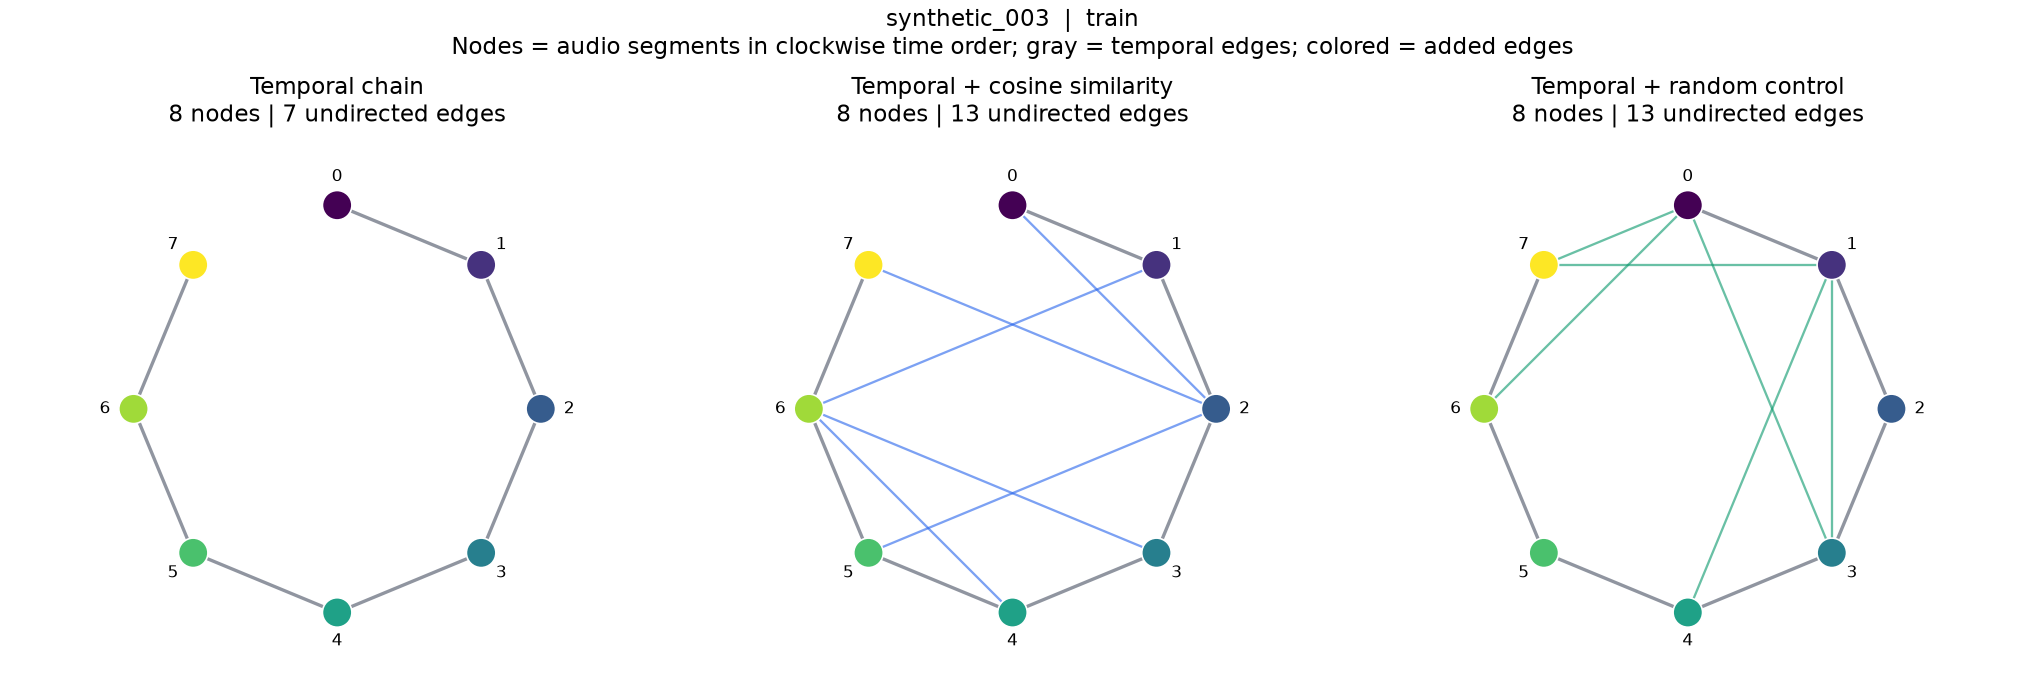

In [6]:
if len(manifest_preview['records']) < 20:
    raise ValueError('At least 20 distinct audio clips are needed for the graph-example deliverable.')
graph_audit = audit_saved_graphs(PROCESSED_MANIFEST)
print('Graph audit:', json.dumps({key: value for key, value in graph_audit.items() if key != 'samples'}, indent=2))
if not graph_audit['valid']:
    raise ValueError('Graph audit failed. Inspect graph_audit.json before training.')
GRAPH_EXAMPLES_DIR = RESULTS_DIR.parent / 'graph_examples'
gallery = visualize_graph_examples(PROCESSED_MANIFEST, GRAPH_EXAMPLES_DIR, count=20, seed=SEED)
print('Gallery:', GRAPH_EXAMPLES_DIR / 'index.html')
example_paths = sorted(GRAPH_EXAMPLES_DIR.glob('*.png'))
assert len(example_paths) >= 20, 'Expected at least 20 graph-example images.'
display(Image(filename=str(example_paths[0])))

Sample: synthetic_000
Nodes x features: (8, 95)
Directed edges: 24
Mel tensor: (1, 32, 251)


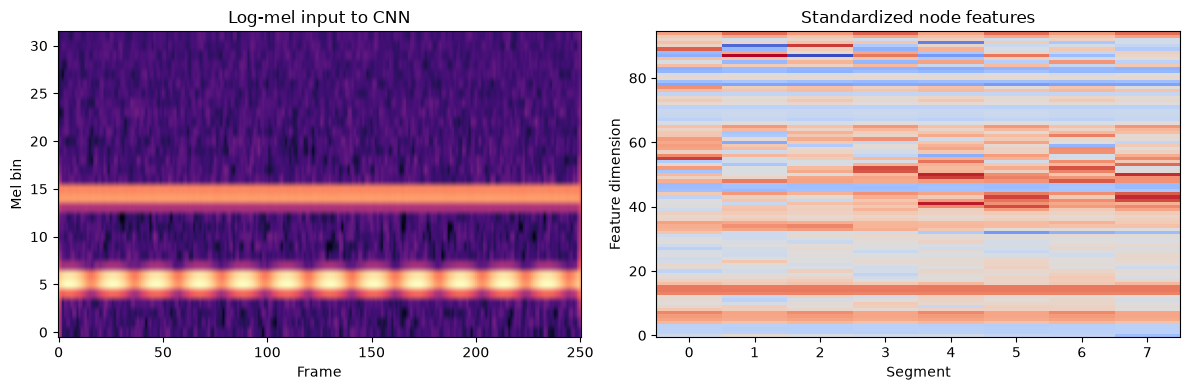

In [7]:
inspection_dataset = ProcessedTask2Dataset(PROCESSED_MANIFEST, 'train', 'temporal_similarity')
sample = inspection_dataset[0]
graph, mel = sample['graph'], sample['mel']
print('Sample:', sample['sample_id'])
print('Nodes x features:', tuple(graph.x.shape))
print('Directed edges:', graph.edge_index.shape[1])
print('Mel tensor:', tuple(mel.shape))
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(mel.squeeze(0), origin='lower', aspect='auto', cmap='magma')
axes[0].set(title='Log-mel input to CNN', xlabel='Frame', ylabel='Mel bin')
axes[1].imshow(graph.x.numpy().T, origin='lower', aspect='auto', cmap='coolwarm')
axes[1].set(title='Standardized node features', xlabel='Segment', ylabel='Feature dimension')
figure.tight_layout()
plt.show()

## 6. Model shape smoke test

GraphSAGE aggregates neighboring node representations, then concatenates mean and max pooling into one graph embedding and predicts multi-label logits. The MLP applies mean/max pooling directly to the same input node features, providing a control without message passing. The CNN operates on the clip's log-mel image. Parameter counts differ and are reported alongside scores; the models are not capacity matched.

In [8]:
loader = DataLoader(inspection_dataset, batch_size=4, shuffle=False, collate_fn=collate_task2)
batch = next(iter(loader))
input_dim = int(batch['graph'].x.shape[1])
num_labels = len(inspection_dataset.label_names)
for model_name in ('mlp', 'gnn', 'cnn'):
    model = build_task2_model(model_name, input_dim=input_dim, num_labels=num_labels,
                             hidden_dim=32, layers=2).eval()
    with torch.no_grad():
        logits = model(batch['mel']) if model_name == 'cnn' else model(batch['graph'])
    assert logits.shape == (len(batch['sample_ids']), num_labels)
    assert torch.isfinite(logits).all(), f'{model_name} produced non-finite logits.'
    parameters = sum(parameter.numel() for parameter in model.parameters())
    print(f'{model_name:>3}: logits={tuple(logits.shape)}, parameters={parameters:,}')

mlp: logits=(4, 3), parameters=6,211
gnn: logits=(4, 3), parameters=8,515
cnn: logits=(4, 3), parameters=23,715


## 7. Train baselines and graph ablations using validation only

The experiment runner trains all five predefined models on the exact same cached cohort and verifies their dataset fingerprint. It writes each model's checkpoint, validation predictions, metrics, runtime, parameter count, and training curves. Checkpoint and threshold selection use validation Macro-F1. Graph selection uses mean validation Macro-F1 across the chosen seeds and is recorded in `selection.json` before test evaluation.

Keep one fixed set of preprocessing parameters and training settings for a comparison. Existing completed experiments are reused without retraining. Choose new result and processed directories when changing the experiment. The default real run uses three training seeds; graph construction uses the fixed preprocessing seed above so every training seed sees the same graph inputs.

In [9]:
RUN_TRAINING = not (RESULTS_DIR / 'experiment.json').is_file()
EPOCHS = 3 if USE_SYNTHETIC else 30
experiment_config = Task2TrainConfig(
    manifest=str(PROCESSED_MANIFEST),
    output_dir=str(RESULTS_DIR),
    hidden_dim=32 if USE_SYNTHETIC else 128,
    layers=2,
    batch_size=6 if USE_SYNTHETIC else 16,
    epochs=EPOCHS,
    patience=5,
    use_pos_weight=False,
    seed=SEED,
    device='auto',
    evaluate_test=False,
)
if RUN_TRAINING:
    experiment_report = run_experiment(experiment_config, seeds=SEEDS, evaluate_test=False)
    print('Shared dataset fingerprint:', experiment_report['dataset_fingerprint'])
else:
    print('Training skipped; inspecting saved results. Use a fresh RESULTS_DIR to train changed settings.')

Training skipped; inspecting saved results. Use a fresh RESULTS_DIR to train changed settings.


## 8. Compare validation metrics and inspect curves

`comparison.csv` contains both baselines and the three graph structures; `graph_ablation.csv` contains the graph controls. Report Macro-F1, Micro-F1, mean average precision (mAP), measured runtime, and parameter counts. mAP summarizes average precision across supported labels; it is not ROC-AUC. Inspect label support because a small available-audio cohort may omit positives for some labels.

Synthetic results describe only this demonstration. A lower GNN score than the CNN, pooled MLP, or random control is a valid outcome and should be retained.

In [10]:
comparison_path = RESULTS_DIR / 'comparison.csv'
selection_path = RESULTS_DIR / 'selection.json'
if comparison_path.is_file() and selection_path.is_file():
    comparison = pd.read_csv(comparison_path)
    display(comparison)
    display(pd.read_csv(RESULTS_DIR / 'graph_ablation.csv'))
    display(pd.read_csv(RESULTS_DIR / 'comparison_aggregate.csv'))
    selection = json.loads(selection_path.read_text(encoding='utf-8'))
    print('Frozen validation selection:', json.dumps(selection, indent=2))
else:
    print('No completed comparison found. Run section 7 first.')

,experiment,model,graph_variant,seed,synthetic,dataset_fingerprint,validation_macro_f1,validation_micro_f1,validation_map,threshold,parameter_count,training_seconds,best_epoch,device,test_macro_f1,test_micro_f1,test_map,test_seconds
0,mlp,mlp,temporal,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.761905,0.782609,1.000000,0.40,6211,0.289559,2,cpu,0.544444,0.526316,1.000000,0.006756
1,cnn,cnn,temporal,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.620491,0.666667,0.750000,0.05,23715,0.385892,1,cpu,0.484127,0.500000,0.777778,0.015692
2,gnn_temporal,gnn,temporal,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.969697,0.947368,0.975556,0.40,8515,0.275154,3,cpu,0.746032,0.750000,1.000000,0.010966
3,gnn_similarity,gnn,temporal_similarity,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.969697,0.947368,0.988889,0.45,8515,0.323350,2,cpu,0.555556,0.714286,0.638889,0.009741
4,gnn_random,gnn,random,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.969697,0.947368,0.958889,0.50,8515,0.252703,1,cpu,0.523810,0.666667,0.555556,0.008349


,experiment,model,graph_variant,seed,synthetic,dataset_fingerprint,validation_macro_f1,validation_micro_f1,validation_map,threshold,parameter_count,training_seconds,best_epoch,device,test_macro_f1,test_micro_f1,test_map,test_seconds
0,gnn_temporal,gnn,temporal,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.969697,0.947368,0.975556,0.40,8515,0.275154,3,cpu,0.746032,0.750000,1.000000,0.010966
1,gnn_similarity,gnn,temporal_similarity,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.969697,0.947368,0.988889,0.45,8515,0.323350,2,cpu,0.555556,0.714286,0.638889,0.009741
2,gnn_random,gnn,random,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.969697,0.947368,0.958889,0.50,8515,0.252703,1,cpu,0.523810,0.666667,0.555556,0.008349


,experiment,validation_macro_f1_mean,validation_macro_f1_std,validation_micro_f1_mean,validation_micro_f1_std,validation_map_mean,validation_map_std,test_macro_f1_mean,test_macro_f1_std,test_micro_f1_mean,test_micro_f1_std,test_map_mean,test_map_std,training_seconds_mean,training_seconds_std,parameter_count_mean,parameter_count_std
0,mlp,0.761905,NaN,0.782609,NaN,1.000000,NaN,0.544444,NaN,0.526316,NaN,1.000000,NaN,0.289559,NaN,6211.0,NaN
1,cnn,0.620491,NaN,0.666667,NaN,0.750000,NaN,0.484127,NaN,0.500000,NaN,0.777778,NaN,0.385892,NaN,23715.0,NaN
2,gnn_temporal,0.969697,NaN,0.947368,NaN,0.975556,NaN,0.746032,NaN,0.750000,NaN,1.000000,NaN,0.275154,NaN,8515.0,NaN
3,gnn_similarity,0.969697,NaN,0.947368,NaN,0.988889,NaN,0.555556,NaN,0.714286,NaN,0.638889,NaN,0.323350,NaN,8515.0,NaN
4,gnn_random,0.969697,NaN,0.947368,NaN,0.958889,NaN,0.523810,NaN,0.666667,NaN,0.555556,NaN,0.252703,NaN,8515.0,NaN


Frozen validation selection: {
  "criterion": "Mean validation Macro-F1 over declared seeds; declaration order breaks ties",
  "selected_experiment": "gnn_temporal",
  "selected_gnn": "gnn_temporal",
  "validation_means": {
    "mlp": 0.7619047619047619,
    "cnn": 0.6204906204906204,
    "gnn_temporal": 0.9696969696969697,
    "gnn_similarity": 0.9696969696969697,
    "gnn_random": 0.9696969696969697
  },
  "seeds": [
    42
  ],
  "runs": [
    {
      "experiment": "mlp",
      "seed": 42,
      "directory": "seed42/mlp",
      "checkpoint": "seed42/mlp/best_model.pt",
      "checkpoint_sha256": "fc47a46b260915a08eee0ae17ea79f9b61785d190ed58c61bf4b2f5cf8bd042e"
    },
    {
      "experiment": "cnn",
      "seed": 42,
      "directory": "seed42/cnn",
      "checkpoint": "seed42/cnn/best_model.pt",
      "checkpoint_sha256": "3abbddcb476fb948046b223d087f84bbe0e56d196e572e104ce001da741be485"
    },
    {
      "experiment": "gnn_temporal",
      "seed": 42,
      "directory": "seed42/

seed42\cnn


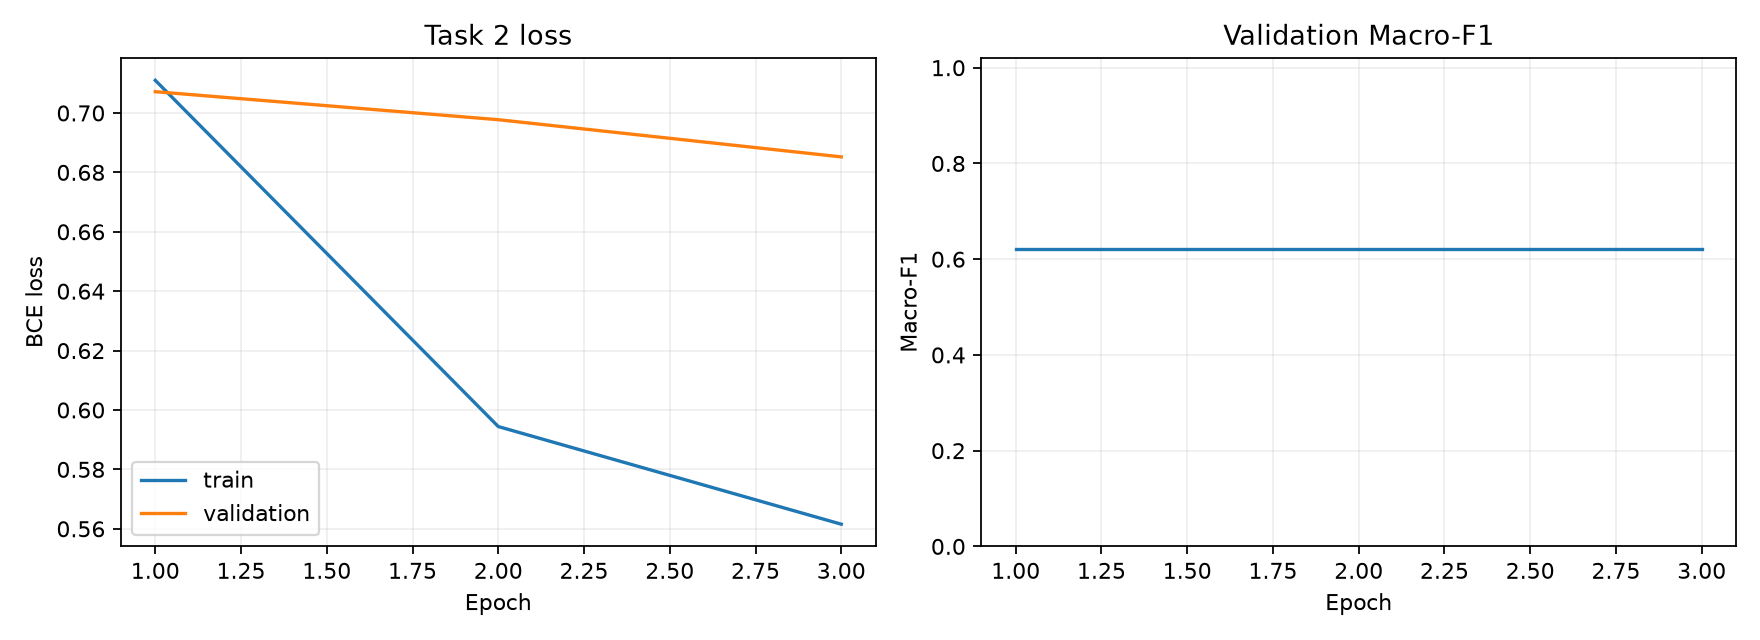

seed42\gnn_random


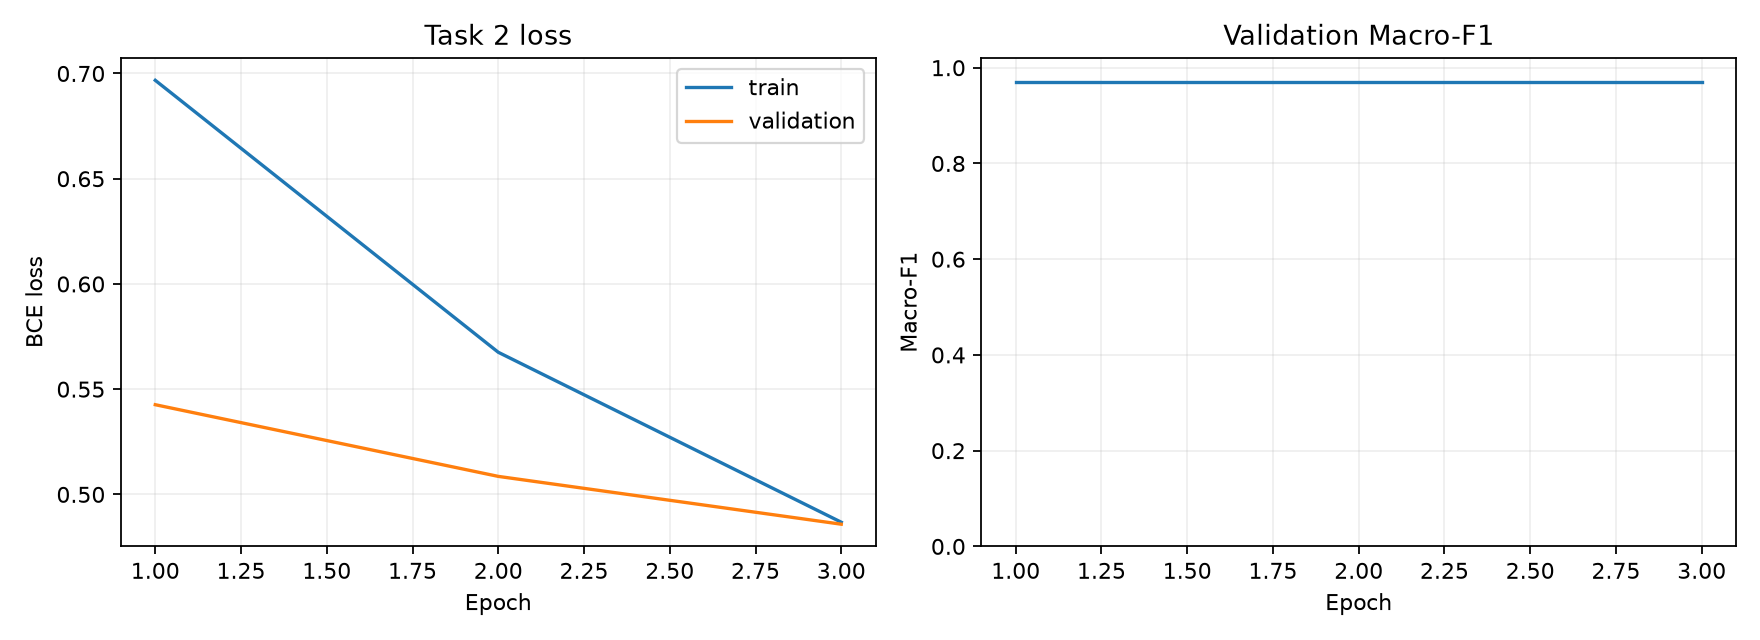

seed42\gnn_similarity


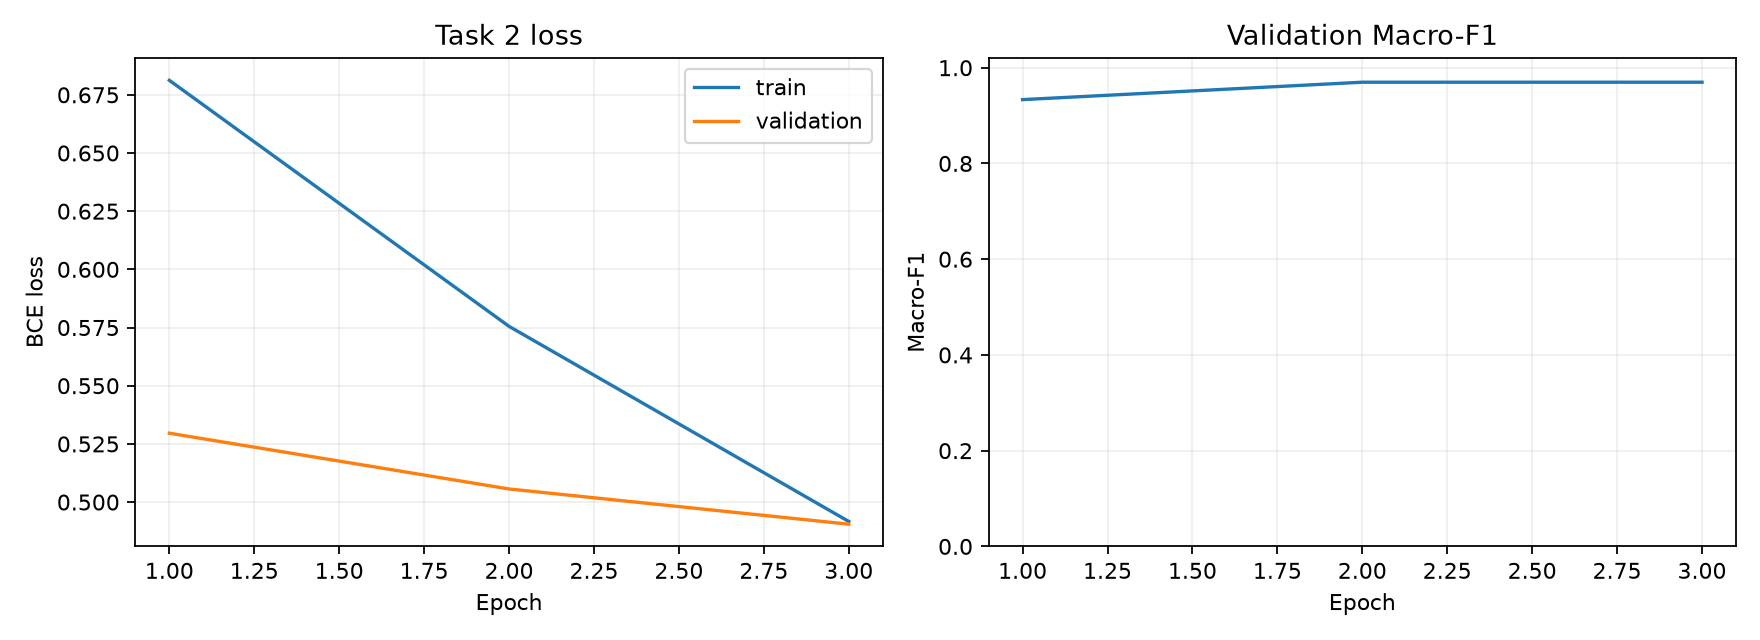

seed42\gnn_temporal


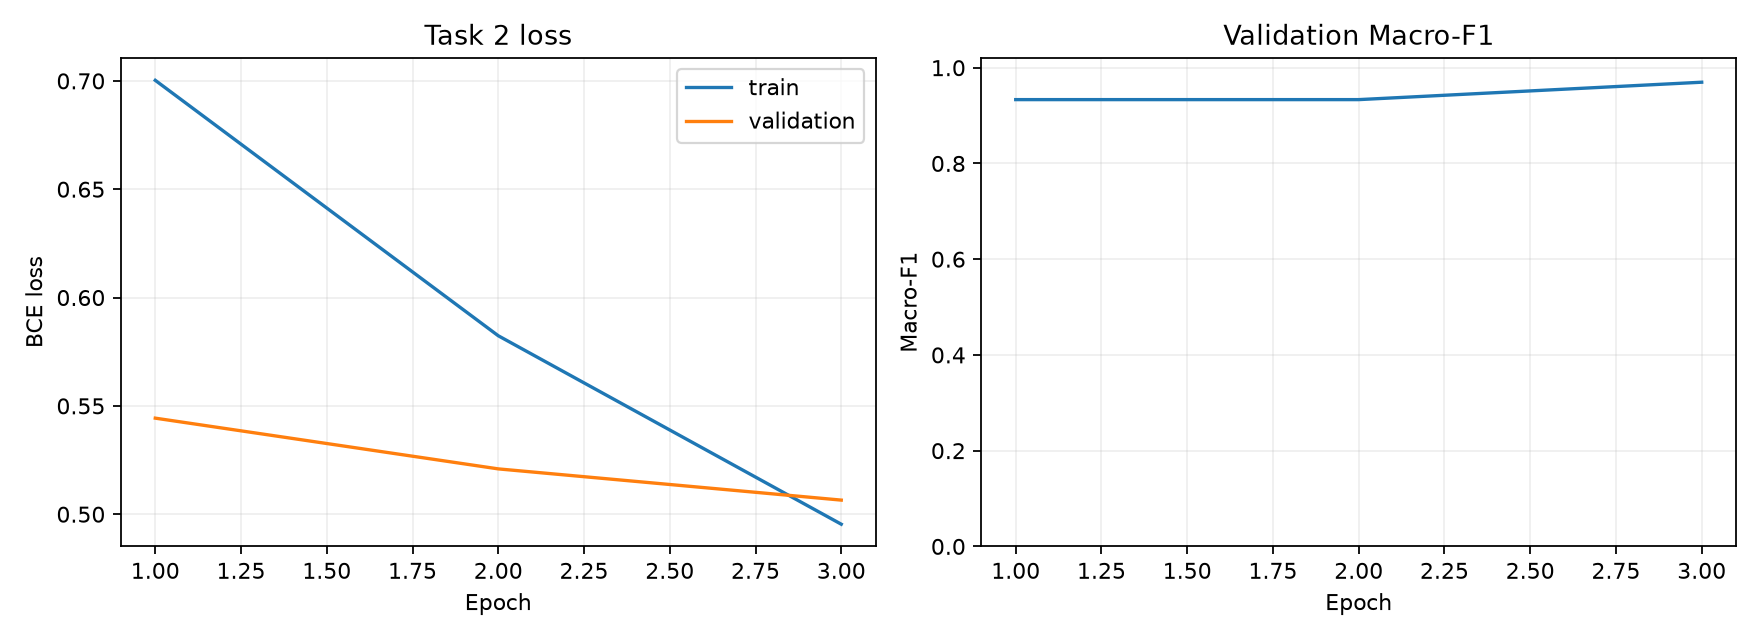

seed42\mlp


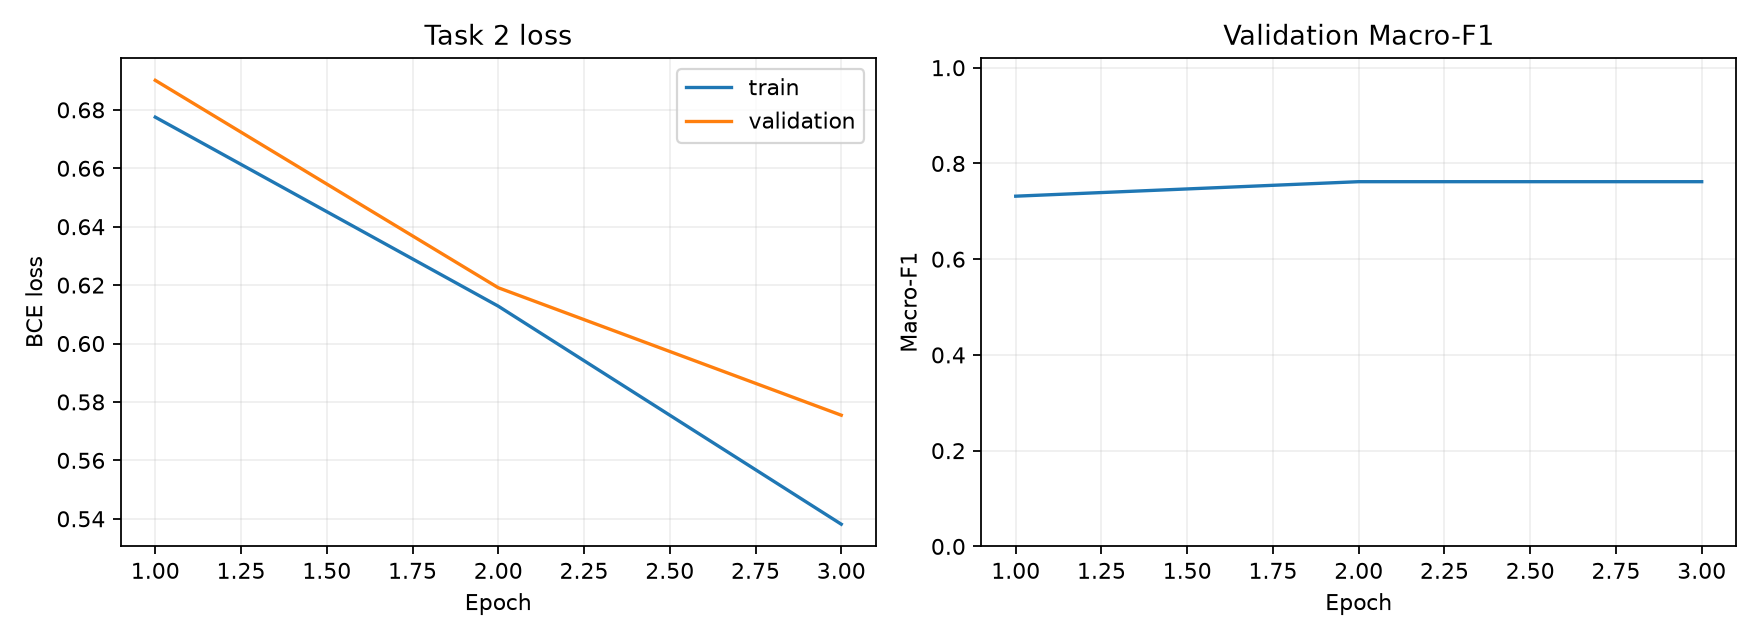

In [11]:
curve_paths = sorted(RESULTS_DIR.glob('seed*/*/training_curves.png'))
if curve_paths:
    for curve_path in curve_paths[:5]:
        print(curve_path.parent.relative_to(RESULTS_DIR))
        display(Image(filename=str(curve_path)))
else:
    print('No saved training curves found yet.')

## 9. Evaluate the frozen test suite without retraining

After fixing all model settings, seeds, and graph choices from validation, set `EVALUATE_FROZEN_TEST = True` and run this cell once. It loads the saved checkpoints and validation thresholds for every predefined baseline/control, verifies the cohort fingerprint, and writes test metrics and predictions. It does not train models or tune on test scores. Keep the validation-selected graph choice even if another graph obtains a higher test score.

Evaluate all frozen models on the same test IDs to make the required GNN/CNN and graph-ablation comparisons. Reuse these predictions for reporting; subsequent tuning requires a new untouched evaluation protocol.

In [12]:
EVALUATE_FROZEN_TEST = False
saved_report_path = RESULTS_DIR / 'experiment.json'
saved_report = json.loads(saved_report_path.read_text(encoding='utf-8'))
if saved_report['evaluated_test']:
    print('Frozen test predictions already exist; reviewing saved outputs without rerunning evaluation.')
    print('Synthetic pipeline diagnostics only.' if USE_SYNTHETIC else 'Frozen real-data test comparison.')
    display(pd.read_csv(RESULTS_DIR / 'comparison.csv'))
elif EVALUATE_FROZEN_TEST:
    experiment_report = evaluate_experiment(RESULTS_DIR, manifest=PROCESSED_MANIFEST, device='auto')
    print('Test evaluated:', experiment_report['evaluated_test'])
    display(pd.read_csv(RESULTS_DIR / 'comparison.csv'))
else:
    print('Test has not been evaluated. Freeze the validation experiment before enabling this cell.')


Frozen test predictions already exist; reviewing saved outputs without rerunning evaluation.
Synthetic pipeline diagnostics only.


,experiment,model,graph_variant,seed,synthetic,dataset_fingerprint,validation_macro_f1,validation_micro_f1,validation_map,threshold,parameter_count,training_seconds,best_epoch,device,test_macro_f1,test_micro_f1,test_map,test_seconds
0,mlp,mlp,temporal,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.761905,0.782609,1.000000,0.40,6211,0.289559,2,cpu,0.544444,0.526316,1.000000,0.006756
1,cnn,cnn,temporal,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.620491,0.666667,0.750000,0.05,23715,0.385892,1,cpu,0.484127,0.500000,0.777778,0.015692
2,gnn_temporal,gnn,temporal,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.969697,0.947368,0.975556,0.40,8515,0.275154,3,cpu,0.746032,0.750000,1.000000,0.010966
3,gnn_similarity,gnn,temporal_similarity,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.969697,0.947368,0.988889,0.45,8515,0.323350,2,cpu,0.555556,0.714286,0.638889,0.009741
4,gnn_random,gnn,random,42,True,9038ed628ae7efd7d354d61d63dd742c70af32dfba828f...,0.969697,0.947368,0.958889,0.50,8515,0.252703,1,cpu,0.523810,0.666667,0.555556,0.008349


## 10. Deliverables and interpretation checklist

| Deliverable | Output location |
| --- | --- |
| Input cohort, label order, inherited splits, audio-availability audit | `INPUT_MANIFEST` |
| Cached raw node features and source fingerprints | `PROCESSED_DIR/raw_features/` |
| Saved node features, mel tensors, and all graph edge variants | `PROCESSED_DIR/samples/` |
| Training-only normalizer and processed manifest | `PROCESSED_DIR/normalization.json`, `manifest.json` |
| Full graph audit | `PROCESSED_DIR/graph_audit.json` |
| At least 20 three-panel graph examples | `PROCESSED_DIR/graph_examples/` |
| GNN, CNN, and MLP checkpoints, metrics, curves, validation predictions | `RESULTS_DIR/seed*/<model>/` |
| All-model and graph-ablation comparisons | `RESULTS_DIR/comparison.csv`, `graph_ablation.csv`, `comparison_aggregate.csv` |
| Validation-based frozen graph selection | `RESULTS_DIR/selection.json` |
| Test predictions and metrics after section 9 | Each model's existing output directory |

Before treating Task 2 as complete, verify real audio coverage, matching labels and split membership across tasks, at least 20 real graph examples, the five trained model variants, and saved test predictions. Report real-data sample counts and exclusions, label support, seed variation, runtimes, parameter counts, and all control results. Synthetic artifacts satisfy software smoke testing only and must remain identified as synthetic.

In [13]:
artifact_summary = {
    'mode': 'synthetic demo; not project performance' if USE_SYNTHETIC else 'real music',
    'input_manifest': str(INPUT_MANIFEST),
    'processed_manifest': str(PROCESSED_MANIFEST),
    'graph_audit_exists': (PROCESSED_DIR / 'graph_audit.json').is_file(),
    'graph_example_pngs': len(list(GRAPH_EXAMPLES_DIR.glob('*.png'))),
    'checkpoints': len(list(RESULTS_DIR.glob('seed*/*/best_model.pt'))),
    'training_curves': len(list(RESULTS_DIR.glob('seed*/*/training_curves.png'))),
    'test_prediction_files': len(list(RESULTS_DIR.glob('seed*/*/test_predictions.npz'))),
    'expected_model_runs': 5 * len(SEEDS),
    'results_dir': str(RESULTS_DIR),
}
print(json.dumps(artifact_summary, indent=2))

{
  "mode": "synthetic demo; not project performance",
  "input_manifest": "C:\\Users\\Roman\\OneDrive\\Documents\\Neural_Project\\results\\task2\\synthetic_verification\\demo_data\\manifest.json",
  "processed_manifest": "C:\\Users\\Roman\\OneDrive\\Documents\\Neural_Project\\results\\task2\\synthetic_verification\\processed\\manifest.json",
  "graph_audit_exists": true,
  "graph_example_pngs": 20,
  "checkpoints": 5,
  "training_curves": 5,
  "test_prediction_files": 5,
  "expected_model_runs": 5,
  "results_dir": "C:\\Users\\Roman\\OneDrive\\Documents\\Neural_Project\\results\\task2\\synthetic_verification\\runs"
}
